# 01 — Nettoyage & Preprocessing
**Objectif :** Charger les données brutes, les nettoyer et identifier les 59 groupes d'expériences.

In [1]:
# ── Chargement & Nettoyage ────────────────────────────────────
import pandas as pd, numpy as np

df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()
df.loc[df['Hydrogen'] < 0, 'Hydrogen'] = 0.0
print(f"Dataset charge : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}  |  Doublons : {df.duplicated().sum()}")

Dataset charge : 3748 lignes × 9 colonnes
Valeurs manquantes : 0  |  Doublons : 0


In [2]:
# ── Informations sur les colonnes ──────────────────────────────
print("\n=== COLONNES DU DATASET ===")
for col in df.columns:
    print(f"  {col:25s} | type: {df[col].dtype} | unique: {df[col].nunique()}")


=== COLONNES DU DATASET ===
  Time                      | type: int64 | unique: 102
  Temperature               | type: int64 | unique: 104
  ProcessTemperature        | type: int64 | unique: 4
  AgentType                 | type: object | unique: 2
  AgentFlow                 | type: float64 | unique: 6
  SampleType                | type: object | unique: 2
  CatalystType              | type: object | unique: 3
  CatalystRatio             | type: float64 | unique: 7
  Hydrogen                  | type: float64 | unique: 1193


In [3]:
# ── Statistiques descriptives ──────────────────────────────────
import warnings; warnings.filterwarnings("ignore")
display(df.describe().round(3))

,Time,Temperature,ProcessTemperature,AgentFlow,CatalystRatio,Hydrogen
count,3748.000,3748.000,3748.000,3748.000,3748.000,3748.000
mean,34.646,677.584,879.883,0.071,6.337,13.587
std,22.345,295.996,90.904,0.053,5.866,11.005
min,0.000,6.000,700.000,0.015,0.000,0.000
25%,16.000,581.000,800.000,0.050,0.000,1.000
50%,32.000,800.000,900.000,0.050,5.000,14.000
75%,50.000,900.000,900.000,0.100,10.000,23.000
max,101.000,1000.000,1000.000,0.400,20.000,37.450


In [4]:
# ── Détection valeurs anormales ────────────────────────────────
print("Valeurs H2 négatives (physiquement impossibles) :")
print(df[df['Hydrogen'] < 0][['Hydrogen']].head())
df.loc[df['Hydrogen'] < 0, 'Hydrogen'] = 0.0
print("-> Corrigées a 0.0")

print(f"\nZéros dans Hydrogen : {(df['Hydrogen']==0).sum()} ({(df['Hydrogen']==0).mean()*100:.1f}%)")

Valeurs H2 négatives (physiquement impossibles) :
Empty DataFrame
Columns: [Hydrogen]
Index: []
-> Corrigées a 0.0

Zéros dans Hydrogen : 715 (19.1%)


In [5]:
# ── Experiment_Group + Shuffle ────────────────────────────────
group_cols = ['ProcessTemperature','AgentType','AgentFlow',
              'SampleType','CatalystType','CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group','Time']).reset_index(drop=True)

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)
print(f"Groupes identifies : {df['Experiment_Group'].nunique()} experiences")

Groupes identifies : 59 experiences


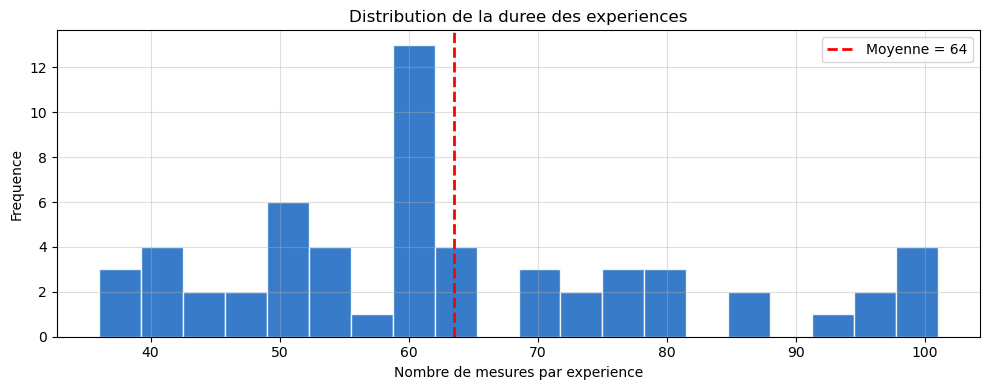

Duree moyenne : 63.5 | min : 36 | max : 101


In [6]:
# ── Distribution des expériences ───────────────────────────────
import matplotlib.pyplot as plt

exp_counts = df.groupby('Experiment_Group').size()
plt.figure(figsize=(10, 4))
plt.hist(exp_counts.values, bins=20, color='#1565C0', edgecolor='white', alpha=0.85)
plt.xlabel('Nombre de mesures par experience'); plt.ylabel('Frequence')
plt.title('Distribution de la duree des experiences')
plt.axvline(exp_counts.mean(), color='red', ls='--', lw=2, label=f'Moyenne = {exp_counts.mean():.0f}')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
print(f"Duree moyenne : {exp_counts.mean():.1f} | min : {exp_counts.min()} | max : {exp_counts.max()}")

In [7]:
# ── Sauvegarder le dataset nettoyé ────────────────────────────
df.to_csv('data_clean.csv', index=False)
print("✅ Dataset nettoyé sauvegardé : data_clean.csv")

✅ Dataset nettoyé sauvegardé : data_clean.csv
